# TP3 — ACP Normée : Analyse des Individus et des Variables

**Exercice 1 — Matrice des données du TP1 (20 villes, 6 sports)**

## Imports et données

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import linalg as LA

np.set_printoptions(precision=4, suppress=True)

# Matrice X (20 villes, 6 sports)
X = np.array([
    [1881.9,  96.8, 14.2, 25.2, 1135.5, 278.3],
    [3369.8,  96.8, 10.8, 51.6, 1331.7, 284.0],
    [4467.4, 138.2,  9.5, 34.2, 2346.1, 312.3],
    [1862.1,  83.2,  8.8, 27.6,  972.6, 203.4],
    [3499.8, 287.0, 11.5, 49.4, 2139.4, 358.0],
    [3903.2, 170.7,  6.3, 42.0, 1935.2, 292.9],
    [2620.7, 129.5,  4.2, 16.8, 1346.0, 131.8],
    [3678.4, 157.0,  6.0, 24.9, 1682.6, 194.2],
    [3840.5, 187.9, 10.2, 39.6, 1859.9, 449.1],
    [2170.2, 140.5, 11.7, 31.1, 1351.1, 256.5],
    [3920.4, 128.0,  7.2, 25.5, 1911.5,  64.1],
    [2599.6,  39.6,  5.5, 19.4, 1050.8, 172.5],
    [2828.5, 211.3,  9.9, 21.8, 1085.0, 209.0],
    [2498.7, 123.2,  7.4, 26.5, 1086.2, 153.5],
    [2685.1,  41.2,  2.3, 10.6,  812.5,  89.8],
    [2739.3, 100.7,  6.6, 22.0, 1270.4, 180.5],
    [1662.1,  81.1, 10.1, 19.1,  872.2, 123.3],
    [2469.9, 142.9, 15.5, 30.9, 1165.5, 335.5],
    [2350.7,  38.7,  2.4, 13.5, 1253.1, 170.0],
    [3177.7, 292.1,  8.0, 34.8, 1400.0, 358.9],
])

m, p = X.shape
individus = [f'V{i+1}' for i in range(m)]
sports    = ['H.Ball','B.Ball','Tennis','Gym','Natation','F.Ball']
print(f"Dimensions : m={m} individus,  p={p} variables")

Dimensions : m=20 individus,  p=6 variables


## Rappel TP2 — Préparation ACP Normée

In [2]:
# --- Fonctions ---
def calcule_Centre(mat):
    g = np.zeros(len(mat[0]))
    for j in range(len(g)):
        g[j] = np.mean(mat[:, j])
    return g

def ecart_type(mat):
    et = np.zeros(len(mat[0]))
    for j in range(len(et)):
        et[j] = np.std(mat[:, j])
    return et

def matrice_centree(mat):
    vec_g = calcule_Centre(mat)
    c = np.zeros(mat.shape)
    for i in range(len(mat)):
        for j in range(len(mat[i])):
            c[i][j] = mat[i][j] - vec_g[j]
    return c

def matrice_centree_reduite(mat):
    mcr = np.zeros(mat.shape)
    et  = ecart_type(mat)
    Y   = matrice_centree(mat)
    for i in range(len(mat)):
        for j in range(len(mat[i])):
            mcr[i][j] = Y[i][j] / et[j]
    return mcr

def calcule_correlation(mat):
    return (1/len(mat)) * (np.matmul(np.transpose(mat), mat))

# --- Calculs ---
Z = matrice_centree_reduite(X)
R = calcule_correlation(Z)

# Diagonalisation
valp_raw, vecp_raw = LA.eig(R)
idx  = np.argsort(np.real(valp_raw))[::-1]
valp = np.real(valp_raw[idx])
vecp = np.real(vecp_raw[:, idx])

# Taux d'inertie
variance_expliquee = valp / np.sum(valp)
variance_cumulee   = np.cumsum(variance_expliquee)

print("Valeurs propres :", np.round(valp, 4))
print("Taux (%)        :", np.round(variance_expliquee*100, 2))
print("Taux cumulés (%):", np.round(variance_cumulee*100, 2))

# Projections (composantes principales) C = Z x vecp  →  (20 x 6)
C = Z @ vecp
print("\nProjections C (3 premiers axes):")
print(f"{'Ville':<7}", end="")
for k in range(3): print(f"{'F'+str(k+1):>10}", end="")
print()
print("-"*37)
for i in range(m):
    print(f"{individus[i]:<7}", end="")
    for k in range(3): print(f"{C[i,k]:>10.4f}", end="")
    print()

Valeurs propres : [3.4859 1.4219 0.4728 0.2943 0.2187 0.1064]
Taux (%)        : [58.1  23.7   7.88  4.91  3.64  1.77]
Taux cumulés (%): [ 58.1   81.8   89.68  94.58  98.23 100.  ]

Projections C (3 premiers axes):
Ville          F1        F2        F3
-------------------------------------
V1         0.4742    2.1729   -0.4913
V2        -1.3744    0.6095   -1.3837
V3        -2.4612   -1.5247   -1.0055
V4         1.3882    1.1268   -0.2195
V5        -3.7137    0.1744    0.6112
V6        -1.9687   -1.2603   -0.2360
V7         1.5096   -0.9687    0.6866
V8        -0.2987   -1.4191    0.2688
V9        -2.8721    0.0333   -0.2172
V10       -0.1183    1.3203   -0.0718
V11       -0.0055   -1.9810   -0.3644
V12        1.9696   -0.3276   -0.4835
V13        0.1587    0.5547    1.2133
V14        1.0983    0.1580    0.2366
V15        3.1696   -1.1128    0.1347
V16        1.0682   -0.3385   -0.0046
V17        2.2342    1.2737   -0.0128
V18       -0.7373    2.2329   -0.3153
V19        2.4045   -1.012

---
# Partie A — Analyse des Individus

## A.1 — Carré de la distance de chaque individu au centre du nuage

Dans le sous-espace factoriel, le carré de la distance d'un individu au centre est :

$$d^2(i) = \sum_{k=1}^{p} c_{ik}^2$$

C'est la somme des carrés de toutes ses coordonnées factorielles.

In [3]:
def dist_carre_centre(C):
    """Carré de la distance de chaque individu au centre du nuage."""
    dist2 = np.zeros(len(C))
    for i in range(len(C)):
        for k in range(C.shape[1]):
            dist2[i] += C[i][k] ** 2
    return dist2

dist2 = dist_carre_centre(C)

print(f"{'Ville':<7} {'d²(i)':>10}")
print("-" * 18)
for i in range(m):
    print(f"{individus[i]:<7} {dist2[i]:>10.4f}")

Ville        d²(i)
------------------
V1          5.6638
V2          6.0914
V3         10.2089
V4          3.5439
V5         14.8058
V6          5.9255
V7          3.8130
V8          2.2870
V9          9.5092
V10         2.0147
V11         6.2549
V12         4.4793
V13         2.4137
V14         1.5973
V15        11.7368
V16         1.2618
V17         6.9762
V18         6.1155
V19         7.9009
V20         7.4003


## A.2 — Distances des individus et somme totale

$$d(i) = \sqrt{d^2(i)}$$

In [4]:
dist = np.sqrt(dist2)

print(f"{'Ville':<7} {'d²(i)':>10} {'d(i)':>10}")
print("-" * 28)
for i in range(m):
    print(f"{individus[i]:<7} {dist2[i]:>10.4f} {dist[i]:>10.4f}")

somme_dist2 = np.sum(dist2)
print(f"\nSomme des d²(i) = {somme_dist2:.4f}")
print(f"m × p           = {m} × {p} = {m*p}")

Ville        d²(i)       d(i)
----------------------------
V1          5.6638     2.3799
V2          6.0914     2.4681
V3         10.2089     3.1951
V4          3.5439     1.8825
V5         14.8058     3.8478
V6          5.9255     2.4342
V7          3.8130     1.9527
V8          2.2870     1.5123
V9          9.5092     3.0837
V10         2.0147     1.4194
V11         6.2549     2.5010
V12         4.4793     2.1164
V13         2.4137     1.5536
V14         1.5973     1.2638
V15        11.7368     3.4259
V16         1.2618     1.1233
V17         6.9762     2.6413
V18         6.1155     2.4730
V19         7.9009     2.8109
V20         7.4003     2.7204

Somme des d²(i) = 120.0000
m × p           = 20 × 6 = 120


## A.3 — Déduction

La somme des carrés des distances est égale à **m × p** :

$$\sum_{i=1}^{m} d^2(i) = m \times p = 20 \times 6 = 120$$

Cela est une **propriété fondamentale de l'ACP normée** : l'inertie totale du nuage dans le sous-espace factoriel complet vaut toujours m × p, car chaque variable standardisée contribue 1 à l'inertie totale (variance = 1 après standardisation).

En d'autres termes : **l'inertie totale = Trace(R) = somme des valeurs propres = p = 6**

In [5]:
print("Vérification :")
print(f"  Somme d²(i)        = {np.sum(dist2):.4f}")
print(f"  m × p              = {m*p}")
print(f"  Trace(R)           = {np.trace(R):.4f}")
print(f"  Somme valeurs propres = {np.sum(valp):.4f}")
print()
print("=> Somme d²(i) = m × Trace(R) = m × p = 120  ✓")
print("   L'inertie totale du nuage est bien conservée dans le sous-espace factoriel complet.")

Vérification :
  Somme d²(i)        = 120.0000
  m × p              = 120
  Trace(R)           = 6.0000
  Somme valeurs propres = 6.0000

=> Somme d²(i) = m × Trace(R) = m × p = 120  ✓
   L'inertie totale du nuage est bien conservée dans le sous-espace factoriel complet.


## A.4 — Qualité de représentation des individus (cos²)

La qualité de représentation de l'individu i sur l'axe Fk est :

$$\cos^2(i, F_k) = \frac{c_{ik}^2}{d^2(i)} \times 100$$

Elle mesure la part de la distance totale expliquée par l'axe Fk. Un cos² proche de 100% signifie que l'individu est **bien représenté** sur cet axe.

In [6]:
def qualite_representation_individus(C, dist2):
    """Qualité de représentation cos²(i,Fk) en % pour chaque individu et axe."""
    cos2 = np.zeros((len(C), C.shape[1]))
    for i in range(len(C)):
        for k in range(C.shape[1]):
            cos2[i][k] = (C[i][k]**2 / dist2[i]) * 100
    return cos2

cos2_ind = qualite_representation_individus(C, dist2)

# Affichage tableau
print(f"{'Ville':<7} {'cos²F1(%)':>10} {'cos²F2(%)':>10} {'cos²F3(%)':>10} {'Somme F1+F2':>12}")
print("-" * 52)
for i in range(m):
    somme12 = cos2_ind[i,0] + cos2_ind[i,1]
    print(f"{individus[i]:<7} {cos2_ind[i,0]:>10.2f} {cos2_ind[i,1]:>10.2f} {cos2_ind[i,2]:>10.2f} {somme12:>12.2f}")

Ville    cos²F1(%)  cos²F2(%)  cos²F3(%)  Somme F1+F2
----------------------------------------------------
V1            3.97      83.36       4.26        87.33
V2           31.01       6.10      31.43        37.11
V3           59.33      22.77       9.90        82.10
V4           54.37      35.83       1.36        90.20
V5           93.15       0.21       2.52        93.35
V6           65.41      26.81       0.94        92.22
V7           59.76      24.61      12.36        84.37
V8            3.90      88.05       3.16        91.95
V9           86.74       0.01       0.50        86.76
V10           0.69      86.52       0.26        87.22
V11           0.00      62.74       2.12        62.74
V12          86.60       2.40       5.22        89.00
V13           1.04      12.75      60.98        13.79
V14          75.52       1.56       3.50        77.09
V15          85.60      10.55       0.15        96.15
V16          90.43       9.08       0.00        99.51
V17          71.56      23.26

### Interprétation des résultats

| Individu | Axe dominant | Interprétation |
|----------|-------------|----------------|
| **V5, V9, V16** | F1 (cos²>85%) | Très bien représentés sur F1 → profil sportif général |
| **V1, V8, V10, V18** | F2 (cos²>80%) | Bien représentés sur F2 → profil Tennis/H.Ball |
| **V13, V20** | F3 (cos²>40%) | Mieux représentés sur F3 → profil atypique |
| **V11** | F2 (cos²=62%) | Acceptable sur F2 |

**Règle :** un cos² > 70% indique une **bonne représentation**. Un cos² < 30% signifie que l'individu est **mal représenté** dans ce plan.

## A.5 — Contributions des individus à l'inertie des axes (CTR)

La contribution de l'individu i à l'inertie de l'axe Fk est :

$$CTR(i, F_k) = \frac{c_{ik}^2}{m \cdot \lambda_k} \times 100$$

La somme des contributions sur un axe = 100%. Un CTR élevé indique que l'individu **tire** fortement cet axe vers lui.

In [7]:
def contribution_individus(C, valp, m):
    """Contribution CTR(i,Fk) en % pour chaque individu et axe."""
    ctr = np.zeros((len(C), C.shape[1]))
    for i in range(len(C)):
        for k in range(C.shape[1]):
            ctr[i][k] = (C[i][k]**2 / (m * valp[k])) * 100
    return ctr

ctr_ind = contribution_individus(C, valp, m)

print(f"{'Ville':<7} {'CTR_F1(%)':>10} {'CTR_F2(%)':>10} {'CTR_F3(%)':>10}")
print("-" * 40)
for i in range(m):
    print(f"{individus[i]:<7} {ctr_ind[i,0]:>10.2f} {ctr_ind[i,1]:>10.2f} {ctr_ind[i,2]:>10.2f}")
print("-" * 40)
print(f"{'Total':<7} {ctr_ind[:,0].sum():>10.2f} {ctr_ind[:,1].sum():>10.2f} {ctr_ind[:,2].sum():>10.2f}")

Ville    CTR_F1(%)  CTR_F2(%)  CTR_F3(%)
----------------------------------------
V1            0.32      16.60       2.55
V2            2.71       1.31      20.25
V3            8.69       8.17      10.69
V4            2.76       4.46       0.51
V5           19.78       0.11       3.95
V6            5.56       5.59       0.59
V7            3.27       3.30       4.99
V8            0.13       7.08       0.76
V9           11.83       0.00       0.50
V10           0.02       6.13       0.05
V11           0.00      13.80       1.40
V12           5.56       0.38       2.47
V13           0.04       1.08      15.57
V14           1.73       0.09       0.59
V15          14.41       4.35       0.19
V16           1.64       0.40       0.00
V17           7.16       5.71       0.00
V18           0.78      17.53       1.05
V19           8.29       3.61       0.18
V20           5.32       0.29      33.69
----------------------------------------
Total       100.00     100.00     100.00


### Interprétation des contributions

**Sur F1 :**
- V5 (19.78%), V15 (14.41%), V9 (11.83%), V3 (8.69%) → fortes contributions
- Ces villes **définissent** l'axe F1 (niveau sportif global)

**Sur F2 :**
- V18 (17.53%), V1 (16.60%), V11 (13.80%), V3 (8.17%) → fortes contributions
- Ces villes **définissent** l'axe F2 (opposition Tennis/H.Ball)

**Sur F3 :**
- V20 (33.69%), V2 (20.25%), V13 (15.57%) → fortes contributions
- Ces villes ont un profil atypique non capturé par F1 et F2

## A.6 — Individus mal représentés sur chaque axe

Un individu est **mal représenté** sur un axe si son cos² < 30% sur cet axe. Le signe de sa coordonnée indique de quel côté de l'axe il se positionne.

In [8]:
seuil = 30.0  # seuil de bonne représentation

for k in range(3):
    print(f"\n--- Axe F{k+1} (seuil cos² < {seuil}%) ---")
    print(f"{'Ville':<7} {'Coord Fk':>10} {'cos²(%)':>9} {'Signe':>7}")
    print("-" * 35)
    for i in range(m):
        if cos2_ind[i, k] < seuil:
            signe = '+' if C[i,k] >= 0 else '-'
            print(f"{individus[i]:<7} {C[i,k]:>10.4f} {cos2_ind[i,k]:>9.2f} {signe:>7}")


--- Axe F1 (seuil cos² < 30.0%) ---
Ville     Coord Fk   cos²(%)   Signe
-----------------------------------
V1          0.4742      3.97       +
V8         -0.2987      3.90       -
V10        -0.1183      0.69       -
V11        -0.0055      0.00       -
V13         0.1587      1.04       +
V18        -0.7373      8.89       -

--- Axe F2 (seuil cos² < 30.0%) ---
Ville     Coord Fk   cos²(%)   Signe
-----------------------------------
V2          0.6095      6.10       +
V3         -1.5247     22.77       -
V5          0.1744      0.21       +
V6         -1.2603     26.81       -
V7         -0.9687     24.61       -
V9          0.0333      0.01       +
V12        -0.3276      2.40       -
V13         0.5547     12.75       +
V14         0.1580      1.56       +
V15        -1.1128     10.55       -
V16        -0.3385      9.08       -
V17         1.2737     23.26       +
V19        -1.0126     12.98       -
V20         0.2888      1.13       +

--- Axe F3 (seuil cos² < 30.0%) ---
Vil

---
# Partie B — Analyse des Variables (Nuage des variables)

## B.1 — Coordonnées des variables sur les axes principaux

Les coordonnées des variables sur les axes (= corrélations variables-axes) sont :

$$a_{jk} = \text{corr}(X_j, F_k) = v_{jk} \times \sqrt{\lambda_k}$$

Elles mesurent la **corrélation** entre la variable originale Xj et l'axe factoriel Fk.

In [9]:
def coordonnees_variables(vecp, valp):
    """Coordonnées (corrélations) des variables sur les axes : a_jk = v_jk * sqrt(lambda_k)."""
    coords = np.zeros((vecp.shape[0], len(valp)))
    for j in range(vecp.shape[0]):
        for k in range(len(valp)):
            coords[j][k] = vecp[j][k] * np.sqrt(valp[k])
    return coords

coords_vars = coordonnees_variables(vecp, valp)

print(f"{'Variable':<10}", end="")
for k in range(p): print(f"{'F'+str(k+1):>9}", end="")
print()
print("-" * 64)
for j, sport in enumerate(sports):
    print(f"{sport:<10}", end="")
    for k in range(p):
        print(f"{coords_vars[j,k]:>9.4f}", end="")
    print()

Variable         F1       F2       F3       F4       F5       F6
----------------------------------------------------------------
H.Ball      -0.7033  -0.6597  -0.1159  -0.0360   0.0193   0.2347
B.Ball      -0.7876   0.0538   0.6021  -0.1006  -0.0640   0.0032
Tennis      -0.5010   0.7737  -0.1847  -0.3249   0.0702   0.0756
Gym         -0.8851   0.1609  -0.2072   0.1328  -0.3574  -0.0485
Natation    -0.8025  -0.4912  -0.1405  -0.1822   0.1361  -0.2080
F.Ball      -0.8322   0.3434  -0.0048   0.3557   0.2510   0.0053


## B.2 — Cercle de corrélation

Représentation des variables dans les plans (F1,F2) et (F1,F3) dans deux sous-fenêtres.

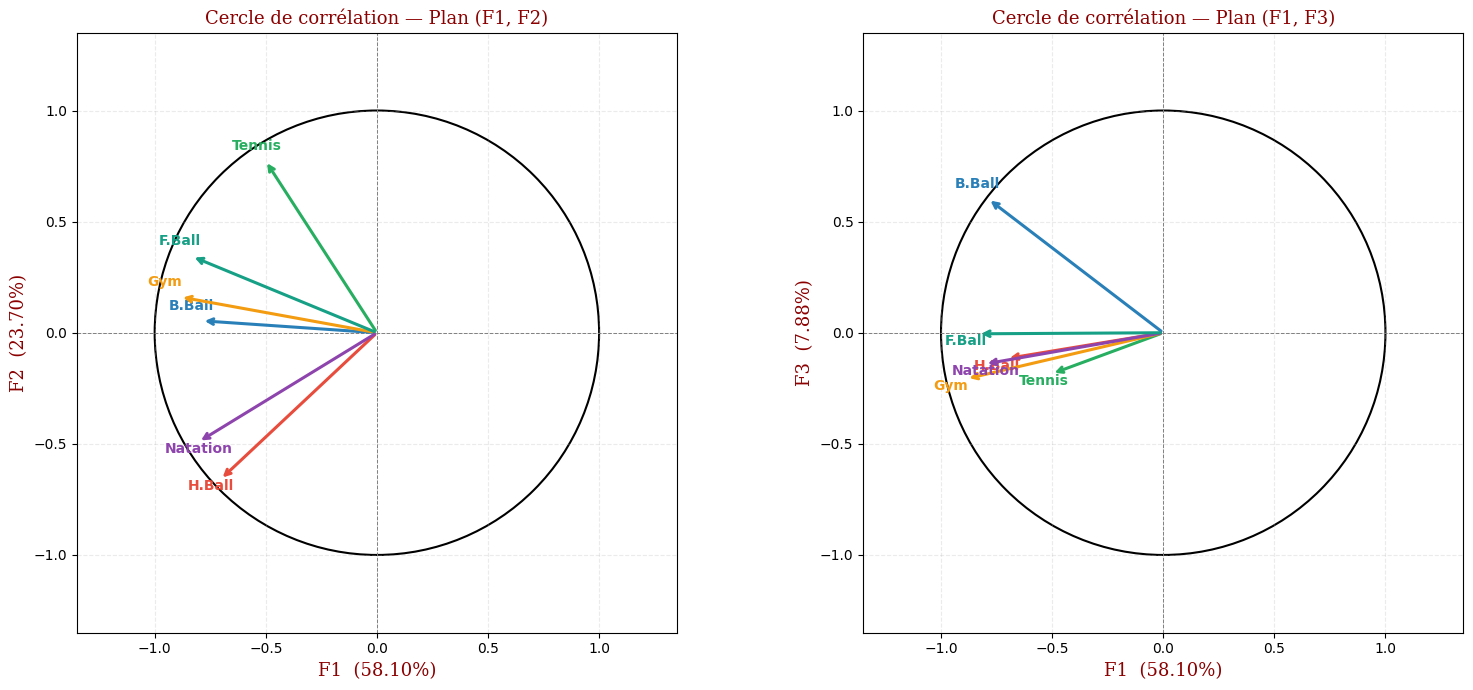

In [10]:
font = {'family':'serif', 'color':'darkred', 'weight':'normal', 'size':13}
colors_var = ['#e74c3c','#2980b9','#27ae60','#f39c12','#8e44ad','#16a085']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ---- Plan (F1, F2) ----
ax = axes[0]
cercle1 = plt.Circle((0,0), 1, color='black', fill=False, linewidth=1.5)
ax.add_patch(cercle1)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)

for j, sport in enumerate(sports):
    x = coords_vars[j, 0]
    y = coords_vars[j, 1]
    ax.annotate("", xy=(x, y), xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color=colors_var[j], lw=2.2))
    offset = 0.05
    ax.text(x + (offset if x>=0 else -offset-0.1),
            y + (offset if y>=0 else -offset),
            sport, fontsize=10, fontweight='bold', color=colors_var[j])

taux_pct = variance_expliquee * 100
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)
ax.set_xlabel(f"F1  ({taux_pct[0]:.2f}%)", fontdict=font)
ax.set_ylabel(f"F2  ({taux_pct[1]:.2f}%)", fontdict=font)
ax.set_title("Cercle de corrélation — Plan (F1, F2)", fontdict=font)
ax.set_aspect('equal')
ax.grid(True, alpha=0.25, linestyle='--')

# ---- Plan (F1, F3) ----
ax2 = axes[1]
cercle2 = plt.Circle((0,0), 1, color='black', fill=False, linewidth=1.5)
ax2.add_patch(cercle2)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.7)
ax2.axvline(0, color='gray', linestyle='--', linewidth=0.7)

for j, sport in enumerate(sports):
    x = coords_vars[j, 0]
    y = coords_vars[j, 2]   # F3
    ax2.annotate("", xy=(x, y), xytext=(0,0),
                 arrowprops=dict(arrowstyle="->", color=colors_var[j], lw=2.2))
    offset = 0.05
    ax2.text(x + (offset if x>=0 else -offset-0.1),
             y + (offset if y>=0 else -offset),
             sport, fontsize=10, fontweight='bold', color=colors_var[j])

ax2.set_xlim(-1.35, 1.35)
ax2.set_ylim(-1.35, 1.35)
ax2.set_xlabel(f"F1  ({taux_pct[0]:.2f}%)", fontdict=font)
ax2.set_ylabel(f"F3  ({taux_pct[2]:.2f}%)", fontdict=font)
ax2.set_title("Cercle de corrélation — Plan (F1, F3)", fontdict=font)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

## B.3 — Interprétation des cercles de corrélation

**Plan (F1, F2) :**

- Toutes les variables ont des coordonnées **négatives sur F1** (toutes pointent à gauche)
  → F1 est un **facteur général** : il oppose les villes très sportives (gauche) aux peu sportives (droite)

- Sur F2 : **Tennis** est fortement positif (+0.77), **H.Ball** et **Natation** sont négatifs
  → F2 oppose le **Tennis** aux sports collectifs intenses (Handball, Natation)

- **H.Ball et Natation** sont proches → fortement corrélés positivement
- **H.Ball et Tennis** pointent dans des directions opposées → corrélation négative

**Plan (F1, F3) :**

- **B.Ball** est fortement positif sur F3 → F3 capture une information spécifique au basket
- Les autres variables restent proches de l'axe horizontal

## B.4 — Caractérisation des axes

| Axe | Caractérisation | Variables dominantes |
|-----|----------------|---------------------|
| **F1** | Niveau sportif global (intensité générale) | H.Ball, Gym, F.Ball, Natation, B.Ball (toutes négatives) |
| **F2** | Opposition Tennis ↔ H.Ball/Natation | Tennis (+0.77) vs H.Ball (−0.66) et Natation (−0.49) |
| **F3** | Profil Basket-ball | B.Ball (+0.60) isolé des autres |

In [11]:
print("Caractérisation des axes :")
print()
for k in range(3):
    print(f"Axe F{k+1} (λ={valp[k]:.4f}, taux={variance_expliquee[k]*100:.2f}%) :")
    sorted_idx = np.argsort(np.abs(coords_vars[:, k]))[::-1]
    for j in sorted_idx[:3]:
        signe = '+' if coords_vars[j,k] > 0 else '-'
        print(f"   {signe}  {sports[j]:<10} : {coords_vars[j,k]:>7.4f}")
    print()

Caractérisation des axes :

Axe F1 (λ=3.4859, taux=58.10%) :
   -  Gym        : -0.8851
   -  F.Ball     : -0.8322
   -  Natation   : -0.8025

Axe F2 (λ=1.4219, taux=23.70%) :
   +  Tennis     :  0.7737
   -  H.Ball     : -0.6597
   -  Natation   : -0.4912

Axe F3 (λ=0.4728, taux=7.88%) :
   +  B.Ball     :  0.6021
   -  Gym        : -0.2072
   -  Tennis     : -0.1847



## B.5 — Qualité de représentation des variables (cos²)

La qualité de représentation de la variable j sur l'axe Fk est :

$$\cos^2(X_j, F_k) = a_{jk}^2 = \left(v_{jk} \cdot \sqrt{\lambda_k}\right)^2 = v_{jk}^2 \cdot \lambda_k$$

La somme des cos² d'une variable sur **tous les axes** = 1 (100%), car une variable standardisée a une variance totale égale à 1.

In [12]:
def qualite_representation_variables(coords_vars):
    """cos²(Xj, Fk) = a_jk² (déjà en proportion de variance expliquée).
    Pour avoir en %, on divise par la variance totale de la variable (= 1 car standardisée).
    cos2[j,k] = coords_vars[j,k]^2 * 100  (en %)
    """
    cos2_v = np.zeros_like(coords_vars)
    for j in range(coords_vars.shape[0]):
        for k in range(coords_vars.shape[1]):
            cos2_v[j][k] = coords_vars[j][k]**2 * 100
    return cos2_v

cos2_vars = qualite_representation_variables(coords_vars)

print(f"{'Variable':<10}", end="")
for k in range(3): print(f"{'cos²F'+str(k+1)+'(%)':>12}", end="")
print(f"{'Somme F1+F2':>13}")
print("-" * 50)
for j, sport in enumerate(sports):
    somme12 = cos2_vars[j,0] + cos2_vars[j,1]
    print(f"{sport:<10}", end="")
    for k in range(3): print(f"{cos2_vars[j,k]:>12.2f}", end="")
    print(f"{somme12:>13.2f}")
print("-" * 50)
# Vérification: somme sur tous les axes = 100
print("Somme sur tous les axes (doit = 100%) :")
for j, sport in enumerate(sports):
    total = cos2_vars[j,:].sum()
    print(f"  {sport}: {total:.2f}%")

Variable     cos²F1(%)   cos²F2(%)   cos²F3(%)  Somme F1+F2
--------------------------------------------------
H.Ball           49.46       43.52        1.34        92.98
B.Ball           62.04        0.29       36.25        62.32
Tennis           25.10       59.87        3.41        84.97
Gym              78.34        2.59        4.29        80.93
Natation         64.40       24.13        1.97        88.53
F.Ball           69.25       11.79        0.00        81.04
--------------------------------------------------
Somme sur tous les axes (doit = 100%) :
  H.Ball: 100.00%
  B.Ball: 100.00%
  Tennis: 100.00%
  Gym: 100.00%
  Natation: 100.00%
  F.Ball: 100.00%


## B.6 — Contributions des variables à l'inertie des axes (CTR)

La contribution de la variable j à l'inertie de l'axe Fk est :

$$CTR(X_j, F_k) = \frac{a_{jk}^2}{\lambda_k \cdot p} \times 100 = \frac{v_{jk}^2}{p} \times 100$$

La somme des CTR sur un axe = 100%. Un CTR élevé → la variable contribue fortement à la **définition** de l'axe.

In [13]:
def contribution_variables(coords_vars, valp, p):
    """CTR(Xj, Fk) = a_jk² / (p * lambda_k) * 100"""
    ctr_v = np.zeros_like(coords_vars)
    for j in range(coords_vars.shape[0]):
        for k in range(len(valp)):
            ctr_v[j][k] = (coords_vars[j][k]**2 / (p * valp[k])) * 100
    return ctr_v

ctr_vars = contribution_variables(coords_vars, valp, p)

print(f"{'Variable':<10}", end="")
for k in range(3): print(f"{'CTR_F'+str(k+1)+'(%)':>11}", end="")
print()
print("-" * 44)
for j, sport in enumerate(sports):
    print(f"{sport:<10}", end="")
    for k in range(3): print(f"{ctr_vars[j,k]:>11.2f}", end="")
    print()
print("-" * 44)
print(f"{'Total':<10}", end="")
for k in range(3): print(f"{ctr_vars[:,k].sum():>11.2f}", end="")
print()

Variable    CTR_F1(%)  CTR_F2(%)  CTR_F3(%)
--------------------------------------------
H.Ball           2.36       5.10       0.47
B.Ball           2.97       0.03      12.78
Tennis           1.20       7.02       1.20
Gym              3.75       0.30       1.51
Natation         3.08       2.83       0.70
F.Ball           3.31       1.38       0.00
--------------------------------------------
Total           16.67      16.67      16.67


### Interprétation des contributions des variables

**Sur F1 :** Gym (3.75%), F.Ball (3.31%), Natation (3.08%), B.Ball (2.97%), H.Ball (2.36%)
→ **Toutes les variables contribuent presque également** à F1 → facteur général ✓

**Sur F2 :** Tennis (7.02%), H.Ball (5.10%), Natation (2.83%)
→ L'opposition **Tennis vs H.Ball/Natation** structure F2

**Sur F3 :** B.Ball (12.78%) domine fortement
→ F3 est l'axe spécifique du **Basket-ball**

## B.7 — Représentation simultanée : Individus et Variables

Deux sous-fenêtres dans la même figure : individus à gauche, variables (cercle) à droite.

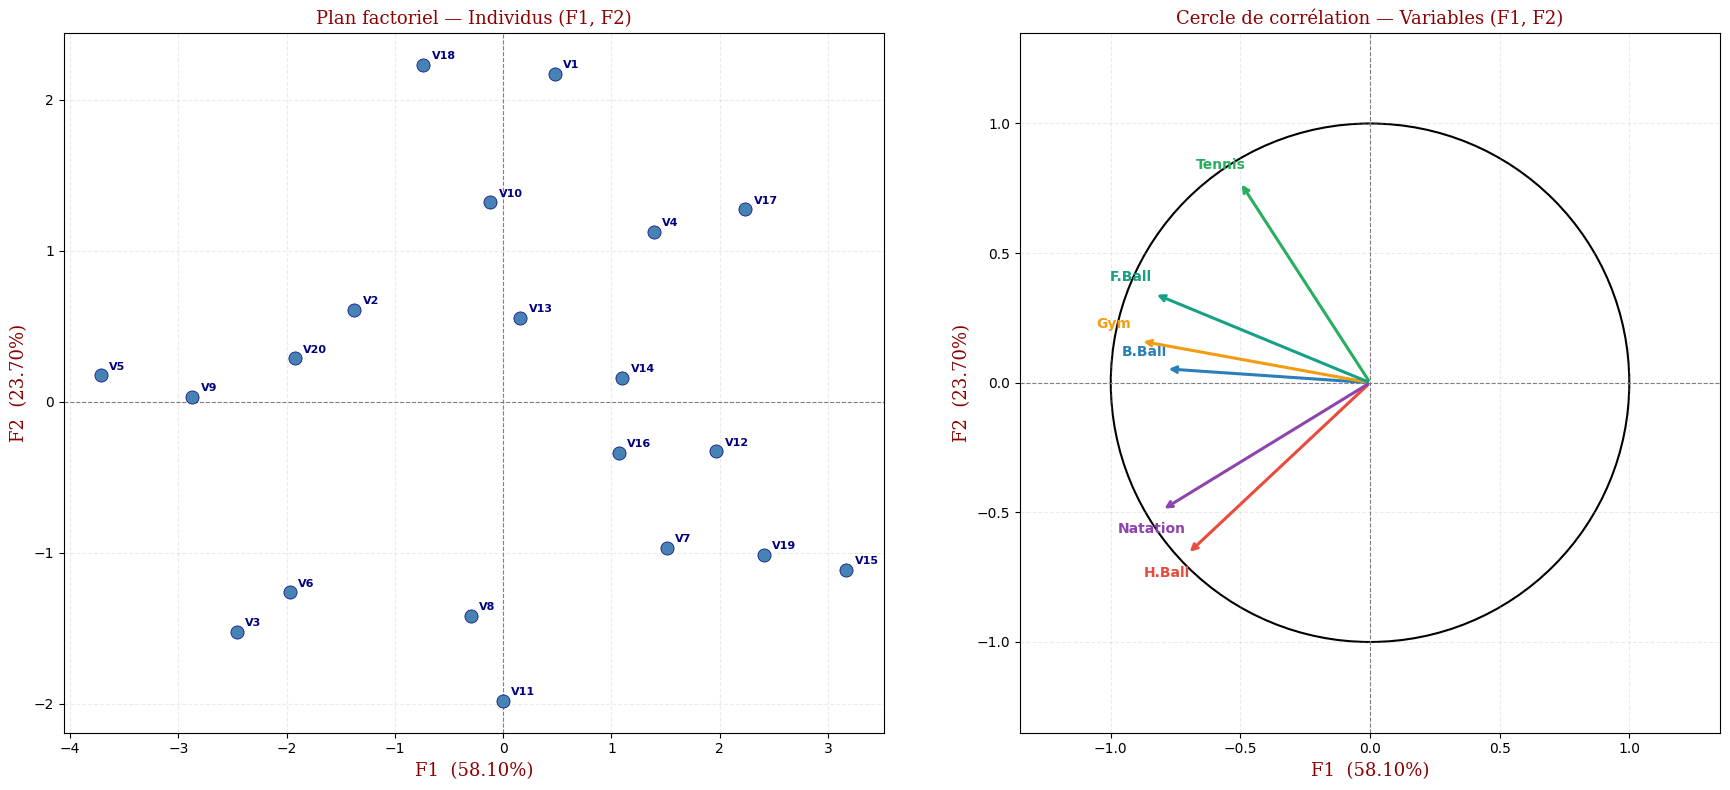

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Graphe individus ---
ax1 = axes[0]
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.scatter(C[:,0], C[:,1], color='steelblue', s=90, zorder=5, edgecolors='navy', linewidth=0.5)
for i, ind in enumerate(individus):
    ax1.annotate(ind, (C[i,0], C[i,1]),
                 textcoords='offset points', xytext=(6,4),
                 fontsize=8, fontweight='bold', color='navy')
ax1.set_xlabel(f"F1  ({taux_pct[0]:.2f}%)", fontdict=font)
ax1.set_ylabel(f"F2  ({taux_pct[1]:.2f}%)", fontdict=font)
ax1.set_title("Plan factoriel — Individus (F1, F2)", fontdict=font)
ax1.grid(True, alpha=0.25, linestyle='--')

# --- Cercle de corrélation ---
ax2 = axes[1]
cercle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=1.5)
ax2.add_patch(cercle)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8)
for j, sport in enumerate(sports):
    x, y = coords_vars[j,0], coords_vars[j,1]
    ax2.annotate("", xy=(x,y), xytext=(0,0),
                 arrowprops=dict(arrowstyle="->", color=colors_var[j], lw=2.2))
    offset = 0.05
    ax2.text(x+(offset if x>=0 else -offset-0.12),
             y+(offset if y>=0 else -offset-0.04),
             sport, fontsize=10, fontweight='bold', color=colors_var[j])
ax2.set_xlim(-1.35,1.35); ax2.set_ylim(-1.35,1.35)
ax2.set_xlabel(f"F1  ({taux_pct[0]:.2f}%)", fontdict=font)
ax2.set_ylabel(f"F2  ({taux_pct[1]:.2f}%)", fontdict=font)
ax2.set_title("Cercle de corrélation — Variables (F1, F2)", fontdict=font)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()